# Neural Network Classification with TensorFlow

A [classification problem](https://en.wikipedia.org/wiki/Statistical_classification) involves predicting whether something is one thing or another.

For example, you might want to:
* Predict whether or not someone has heart disease based on their health parameters. This is called **binary classification** since there are only two options.
* Decide whether a photo of is of food, a person or a dog. This is called **multi-class classification** since there are more than two options.
* Predict what categories should be assigned to a Wikipedia article. This is called **multi-label classification** since a single article could have more than one category assigned.


## What we're going to cover

Specifically, we're going to go through doing the following with TensorFlow:
- Architecture of a classification model
- Input shapes and output shapes
  - `X`: features/data (inputs)
  - `y`: labels (outputs)
    - "What class do the inputs belong to?"
- Creating custom data to view and fit
- Steps in modelling for binary and mutliclass classification
  - Creating a model
  - Compiling a model
    - Defining a loss function
    - Setting up an optimizer
      - Finding the best learning rate
    - Creating evaluation metrics
  - Fitting a model (getting it to find patterns in our data)
  - Improving a model
- The power of non-linearity
- Evaluating classification models
  - Visualizng the model
  - Looking at training curves
  - Compare predictions to ground truth (using our evaluation metrics).

#### Typical architecture of a classification neural network

The architecture of a classification neural network can widely vary depending on the problem you're working on.

However, there are some fundamentals all deep neural networks contain:
* An input layer.
* Some hidden layers.
* An output layer.

Much of the rest is up to the data analyst creating the model.

The following are some standard values you'll often use in your classification neural networks.

| **Hyperparameter** | **Binary Classification** | **Multiclass classification** |
| --- | --- | --- |
| Input layer shape | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited | Same as binary classification |
| Neurons per hidden layer | Problem specific, generally 10 to 100 | Same as binary classification |
| Output layer shape | 1 (one class or the other) | 1 per class (e.g. 3 for food, person or dog photo) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) | Same as binary classification |
| Output activation | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) | [Softmax](https://en.wikipedia.org/wiki/Softmax_function) |
| Loss function | [Cross entropy](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression) ([`tf.keras.losses.BinaryCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy) in TensorFlow) | Cross entropy ([`tf.keras.losses.CategoricalCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy) in TensorFlow) |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) | Same as binary classification |

Table 1: Typical architecture of a classification network. Source: Adapted from page 295 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

#### Creating data to view and fit

We could start by importing a classification dataset but let's practice making some of our own classification data.

Since classification is predicting whether something is one thing or another, let's make some data to reflect that.

To do so, we'll use Scikit-Learn's [`make_circles()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html#sklearn.datasets.make_circles) function.

In [1]:
# Importing Necessary Libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Dataset from Scikit=Learn:

from sklearn.datasets import make_circles

X, y= make_circles(n_samples= 1000,
                  noise= 0.03,
                  random_state= 42)

In [5]:
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
X[:10], y[:10]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343],
        [-0.47964637,  0.67643477],
        [-0.01364836,  0.80334872],
        [ 0.77151327,  0.14775959],
        [-0.16932234, -0.79345575],
        [-0.1214858 ,  1.02150905]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [8]:
# Creating Dataframe from Data:

circles = pd.DataFrame({'X0': X[:, 0],
                       'X1': X[:, 1],
                       'Label': y})

In [9]:
circles.head()

,X0,X1,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [10]:
# Checking how many Lables are there:
circles['Label'].value_counts()

Label
1    500
0    500
Name: count, dtype: int64

Alright, looks like we're dealing with a **binary classification** problem. It's binary because there are only two labels (0 or 1).

If there were more label options (e.g. 0, 1, 2, 3 or 4), it would be called **multiclass classification**.

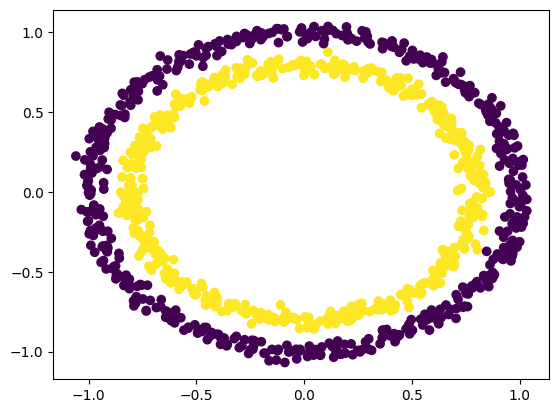

In [11]:
# Visualizing The Data:
plt.scatter(circles['X0'],
           circles['X1'],
           c= circles['Label'])
plt.show()

How about we try and build a model to classify yellow or purple dots? As in, a model which is able to distinguish yellow from purple dots.

> Before pushing forward, you might want to spend 10 minutes playing around with the [TensorFlow Playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=2,2&seed=0.93799&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=true&regularizationRate_hide=true&batchSize_hide=true). Try adjusting the different hyperparameters you see and click play to see a neural network train.

#### Input and output shapes

One of the most common issues you'll run into when building neural networks is shape mismatches.

More specifically, the shape of the input data and the shape of the output data.

In our case, we want to input `X` and get our model to predict `y`.

So let's check out the shapes of `X` and `y`.

In [12]:
# Checking Shapes of Features nad Label:

# Features:
print(X.shape)

# Label:
print(y.shape)

(1000, 2)
(1000,)


In [13]:
# Checking a Single Sample of Data and it's Lable:
X[0], y[0]

(array([0.75424625, 0.23148074]), 1)

Alright, so we've got two `X` features which lead to one `y` value.

This means our neural network input shape will has to accept a tensor with at least one dimension being two and output a tensor with at least one value.

>`y` having a shape of (1000,) can seem confusing. However, this is because all `y` values are actually scalars (single values) and therefore don't have a dimension. For now, think of your output shape as being at least the same value as one example of `y` (in our case, the output from our neural network has to be at least one value).

#### Steps in modelling

Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the [functional](https://www.tensorflow.org/guide/keras/functional) or [sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)) or import a previously built model (known as transfer learning).
2. **Compiling a model** - defining how a model's performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).
3. **Fitting a model** - letting the model try to find patterns in the data (how does `X` get to `y`).

In [14]:
# Buiding a Base Model:

tf.random.set_seed(42)

model_1 = Sequential()
model_1.add(Dense(units= 1))
model_1.compile(optimizer= 'sgd',
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])
model_1.fit(X, y, epochs= 10)

I0000 00:00:1767704850.648118     754 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/10


2026-01-06 13:07:32.225429: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d83d0005b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-06 13:07:32.225464: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-06 13:07:32.344403: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-06 13:07:32.518876: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5046 - loss: 5.8831

I0000 00:00:1767704854.416942    2145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4780 - loss: 5.7171
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4710 - loss: 4.9480
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5040 - loss: 7.1859
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5350 - loss: 6.7244
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5580 - loss: 6.5160
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5750 - loss: 6.3226
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5790 - loss: 6.1526
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5830 - loss: 6.1280
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5810 - loss: 6.0678
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5820 - loss: 6.0262


Looking at the accuracy metric, our model performs poorly (58% accuracy on a binary classification problem is the equivalent of guessing).

Let's try Training for Longer.

In [15]:
model_1.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5830 - loss: 6.0261
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5820 - loss: 6.0260
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5820 - loss: 6.0259
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5820 - loss: 6.0259
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5820 - loss: 6.0258
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5820 - loss: 6.0258
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5820 - loss: 6.0258
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5820 - loss: 6.0258
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5820 - loss: 6.0257
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5820 - loss: 6.0257
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5820 - loss: 6.0257
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy:

Looks like The Model Accuracy is stuck at 58.20 - 58.30%, which is still very poor.

In [16]:
# Another Model with extra Layer:

tf.random.set_seed(42)

model_2 = Sequential()

model_2.add(Dense(units= 1))
model_2.add(Dense(units= 1))

model_2.compile(optimizer= 'sgd',
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])

model_2.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4910 - loss: 1.6317
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4880 - loss: 0.7060
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4720 - loss: 0.6966
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4770 - loss: 0.6951
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4520 - loss: 0.6948
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4510 - loss: 0.6947
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4410 - loss: 0.6947
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4500 - loss: 0.6947
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4530 - loss: 0.6947
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4540 - loss: 0.6947
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4550 - loss: 0.6947
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy

Accuracy of 45% is even worse than first model, and even worse than guessing.

#### Improving a model

To improve our model, we can alter almost every part of the 3 steps we went through before.

1. **Creating a model** - here you might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. **Compiling a model** - you might want to choose a different optimization function (such as the [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) optimizer, which is usually pretty good for many problems) or perhaps change the learning rate of the optimization function.
3. **Fitting a model** - perhaps you could fit a model for more epochs (leave it training for longer).

![various options you can use to improve a neural network model](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/02-improving-a-model-from-model-perspective.png)
*There are many different ways to potentially improve a neural network. Some of the most common include: increasing the number of layers (making the network deeper), increasing the number of hidden units (making the network wider) and changing the learning rate. Because these values are all human-changeable, they're referred to as [hyperparameters](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning)) and the practice of trying to find the best hyperparameters is referred to as [hyperparameter tuning](https://en.wikipedia.org/wiki/Hyperparameter_optimization).*

In [19]:
# Adding More Neurons, Layers and Changing Optimizer:

tf.random.set_seed(42)

model_3 = Sequential()

model_3.add(Dense(units= 100))
model_3.add(Dense(units= 10))
model_3.add(Dense(units= 1))

model_3.compile(optimizer= 'adam',
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])

model_3.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.4810 - loss: 3.0223
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4780 - loss: 0.7209
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5070 - loss: 0.6950
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4860 - loss: 0.6984
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4830 - loss: 0.6989
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4760 - loss: 0.6995
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4780 - loss: 0.7000
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4760 - loss: 0.7004
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4780 - loss: 0.7007
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4800 - loss: 0.7009
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4810 - loss: 0.7011
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy

Still, Around Same Accuracy!

Let's make some visualizations to see what's happening.

Whenever your model is performing strangely or there's something going on with your data you're not quite sure of, remember to **Visualize**. Inspect your data, inspect your model, inpsect your model's predictions.

To visualize our model's predictions we're going to create a function `plot_decision_boundary()` which:
* Takes in a trained model, features (`X`) and labels (`y`).
* Creates a [meshgrid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) of the different `X` values.
* Makes predictions across the meshgrid.
* Plots the predictions as well as a line between the different zones (where each unique class falls).

If you're ever unsure of what a function does, try unraveling it and writing it line by line for yourself to see what it does. Break it into small parts and see what each part outputs.

In [20]:
import numpy as np

def plot_decision_boundary(model, X, y):
  """
  Plots the decision boundary created by a model predicting on X.
  This function has been adapted from two phenomenal resources:
   1. CS231n - https://cs231n.github.io/neural-networks-case-study/
   2. Made with ML basics - https://github.com/GokuMohandas/MadeWithML/blob/main/notebooks/08_Neural_Networks.ipynb
  """
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values (we're going to predict on all of these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together: https://numpy.org/devdocs/reference/generated/numpy.c_.html

  # Make predictions using the trained model
  y_pred = model.predict(x_in)

  # Check for multi-class
  if model.output_shape[-1] > 1: # checks the final dimension of the model's output shape, if this is > (greater than) 1, it's multi-class
    print("doing multiclass classification...")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classifcation...")
    y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)

  # Plot decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
doing binary classifcation...


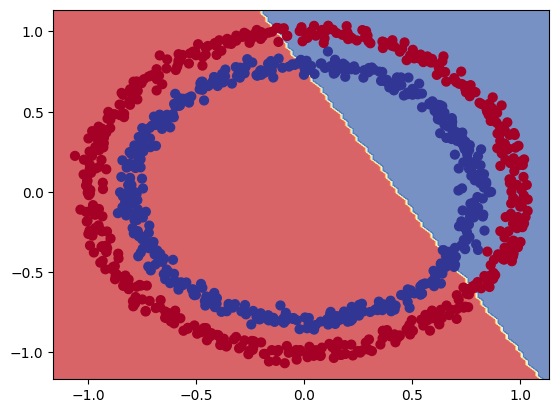

In [21]:
# Let's check how our model is working in finding decision boundry between classes:

plot_decision_boundary(model= model_3, 
                      X= X,
                      y= y)

Looks like our model is trying to draw a straight line through the data.

The main issue is our data isn't separable by a straight line.

In a regression problem, our model might work.

In [22]:
# Trying Same Model on Regression Data:

#Creating Regression Data:
X_reg = tf.range(start= 0, limit= 1000, delta= 5)
y_reg = tf.range(start= 100, limit= 1100, delta= 5)

# Train Test Split:
X_reg_train = X_reg[:150]
X_reg_test = X_reg[150:]
y_reg_train = y_reg[:150]
y_reg_test = y_reg[150:]

In [23]:
print(X_reg_train.shape, X_reg_test.shape, y_reg_train.shape, y_reg_test.shape)

(150,) (50,) (150,) (50,)


In [24]:
# Building Model Same as 'model_3' for Regression:

tf.random.set_seed(42)

model_3_reg = Sequential()

model_3_reg.add(Dense(units= 100))
model_3_reg.add(Dense(units= 10))
model_3_reg.add(Dense(units= 1))

model_3_reg.compile(optimizer= 'adam',
                   loss= 'mae',
                   metrics= ['mae'])

model_3_reg.fit(tf.reshape(X_reg_train, shape= [150,1]),
               y_reg_train,
               epochs= 200)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - loss: 485.7678 - mae: 485.7678
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 349.5701 - mae: 349.5701
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 212.8783 - mae: 212.8783
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 79.3092 - mae: 79.3092  
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 74.5571 - mae: 74.5571
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 89.4722 - mae: 89.4722  
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 58.3795 - mae: 58.3795
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 48.7339 - mae: 48.7339
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 47.9499 - mae: 47.9499
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 44.3808 - mae: 44.3808
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 44.7531 - mae: 44.7531
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 41.6424 - mae: 41.6424
Epoch 13/200
5

In [25]:
# Making Predictions on Regression Test Data:

y_reg_pred = model_3_reg.predict(y_reg_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step


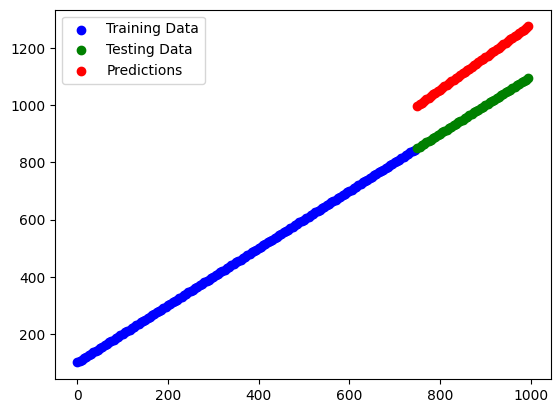

In [26]:
# Plotting Regression Training and Test Data with Predictions:

plt.scatter(X_reg_train, y_reg_train, c= "blue", label= "Training Data")
plt.scatter(X_reg_test, y_reg_test, c= "green", label= "Testing Data")
plt.scatter(X_reg_test, y_reg_pred, c= "red", label= "Predictions")
plt.legend()
plt.show()

Okay, the predictions aren't perfect (if the predictions were perfect, the red would line up with the green), but they look better than complete guessing.

So this means our model must be learning something.

There must be something we're missing out on for our classification problem.

`Introducing Non-Linearity in the Model Using Activation Functions in Hidden Layer:`

In [27]:
tf.random.set_seed(42)

model_4 = Sequential()

model_4.add(Dense(units= 4, activation= 'relu'))
model_4.add(Dense(units= 4, activation= 'relu'))
model_4.add(Dense(units= 1))

model_4.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics = ['accuracy'])

model_4.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4350 - loss: 0.8692
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4370 - loss: 0.7123
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4620 - loss: 0.6954
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5300 - loss: 0.6836
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5590 - loss: 0.6766
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6110 - loss: 0.6653
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6890 - loss: 0.6449
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7230 - loss: 0.6121
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7610 - loss: 0.5448
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8470 - loss: 0.4215
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9490 - loss: 0.2421
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accurac

In [28]:
# Model Evaluation:
model_4.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7400 - loss: 4.0967


[4.096667289733887, 0.7400000095367432]

Accuracy is Still Outrageous.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classifcation...


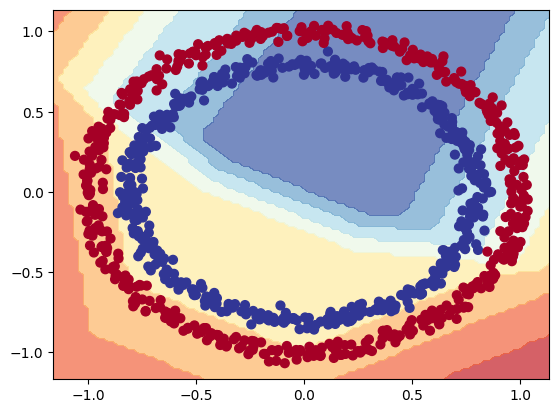

In [29]:
# Plotting Predictions:

plot_decision_boundary(model= model_4,
                      X= X,
                      y= y)

This time we'll change the activation function on our output layer too. Remember the architecture of a classification model? For binary classification, the output layer activation is usually the [Sigmoid activation function](https://www.tensorflow.org/api_docs/python/tf/math/sigmoid).

In [32]:
# Changing Activation Function in Output Layer:

tf.random.set_seed(42)

model_5 = Sequential()

model_5.add(Dense(units= 4, activation= 'relu'))
model_5.add(Dense(units= 4, activation= 'relu'))
model_5.add(Dense(units= 1, activation= 'sigmoid'))

model_5.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
                loss= tf.keras.losses.BinaryCrossentropy,
                metrics= ['accuracy'])

model_5.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5220 - loss: 0.7017
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5120 - loss: 0.6874
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5420 - loss: 0.6795
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5610 - loss: 0.6710
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5720 - loss: 0.6626
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5980 - loss: 0.6506
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6550 - loss: 0.6337
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7140 - loss: 0.6101
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7610 - loss: 0.5802
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7700 - loss: 0.5498
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7790 - loss: 0.5206
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy

HOORAY!!!! We have almost 100% Accuracy.

In [33]:
# Model Evaluation:
model_5.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9930 - loss: 0.0211


[0.021100198850035667, 0.9929999709129333]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classifcation...


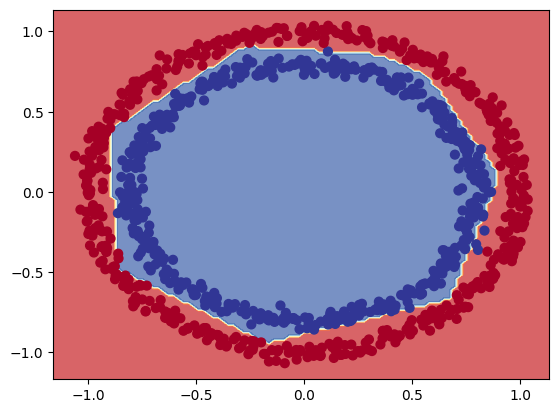

In [34]:
# Plotting Predictions:
plot_decision_boundary(model= model_5,
                      X= X,
                      y= y)

> 🔑 **Note:** The combination of **linear (straight lines) and non-linear (non-straight lines) functions** is one of the key fundamentals of neural networks.

Think of it like this:

If I gave you an unlimited amount of straight lines and non-straight lines, what kind of patterns could you draw?

That's essentially what neural networks do to find patterns in data.

Now you might be thinking, "but I haven't seen a linear function or a non-linear function before..."

Oh but you have.

We've been using them the whole time.

They're what power the layers in the models we just built.

To get some intuition about the activation functions we've just used, let's create them and then try them on some toy data.